## Imports

In [3]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

In [4]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### Functions

In [5]:
class Plot():
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._geometry = Geometry
        
    def get_image_intensity(self, title = "Model", fig_size = 7,  add_fourier_resolution = False, log_norm = False, deprojected = False):
        frank2d = self._frank2d
        Nx = frank2d._Nx
        Ny = frank2d._Ny
        dx = frank2d._FT._dx*rad_to_arcsec
        dy = frank2d._FT._dy*rad_to_arcsec
        Rout = frank2d._Rmax*rad_to_arcsec
        x = (frank2d._FT._Xn*rad_to_arcsec).reshape(Nx, Ny)
        y = (frank2d._FT._Yn*rad_to_arcsec).reshape(Nx, Ny)
        I = frank2d.sol_intensity.reshape(Nx, Ny)

        if deprojected:
            inc_r = self._geometry._inc*deg_to_rad
            pa_r = self._geometry._pa*deg_to_rad

            cos_i = np.cos(inc_r)
            cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

            x = (x * cos_pa + y * sin_pa) / cos_i
            y = (x *-sin_pa + y * cos_pa)
    
        # Coordenadas del pixel que quieres mostrar
        pixel_x, pixel_y = Nx//2, Ny//2
        pixel_value = I[pixel_y, pixel_x]


        fig, ax = plt.subplots(1, 1, figsize=(fig_size, fig_size))
        axs = [ax]
        
        norm = LogNorm() if log_norm else None

        # Primer subplot.
        plot = axs[0].pcolormesh(x, y, I, cmap='magma', norm=norm, vmin = 0 , vmax =4e10)
        axs[0].invert_xaxis()
        cmap = plt.colorbar(plot, ax=axs[0], shrink = 0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)
        

        axs[0].set_title(title)
        axs[0].set_xlabel("dRa ['']")
        axs[0].set_ylabel("dDec ['']")

        xlim = axs[0].get_xlim()
        ylim = axs[0].get_ylim()

        axs[0].text(
            xlim[0] + 0.1 * (xlim[1] - xlim[0]),  # 10% desde el borde izquierdo
            ylim[0] + 0.1 * (ylim[1] - ylim[0]),  # 10% desde el borde inferior
            r'  $N^{2}$ pixels,  N = ' + str(Nx) + '  ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
        )


        plt.gca().set_aspect('equal')

        plt.show()


    def get_several_images(self, data, params, n_plots = 9, rtol = 1e-7, transform = "2fft"):
        u, v, Vis, Weights = data
        m, c, l = params

        I_array = []
        Vis_array = []
        frank2d = self._frank2d

        for i in range(0, n_plots):
            start_time = time.time()
            #----------------------
            print("fit : "+ str(i))
            frank2d.fit(u, v, Vis, Weights, kernel_params = [m[i], c[i], l[i]],
                         rtol = rtol, transform = transform)

            Vis_array.append(frank2d.sol_visibility)
            I_array.append(frank2d.sol_intensity)
            #----------------------
            end_time = time.time()
            execution_time = end_time - start_time
            print(f'total time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
            print(' with ' + f' m = {m[i]:.1f}, c = {c[i]:.1f}, l = {l[i]:.1e} ') 
            print(".....................")


        n_plots = int(np.sqrt(n_plots))

        fig, axs = plt.subplots(n_plots, n_plots, figsize=(18, 14))

        plt.subplots_adjust(wspace=0.2, hspace=0.3)
        x, y = frank2d._FT._x*const.rad_to_arcsec, frank2d._FT._y*const.rad_to_arcsec

        k = 0
        for i in range(n_plots):
            for j in range(n_plots):
                I = I_array[k].reshape(frank2d._Nx, frank2d._Ny).T
                plot = axs[i, j].pcolormesh(y, x, I, cmap='magma')
                
                axs[i, j].invert_xaxis()
                
                cmap = plt.colorbar(plot, ax=axs[i, j])

                if i == j and i == (0):
                    axs[i, j].set_title(f'AS209 at 1mm')
                    axs[i, j].set_xlabel("dRa ['']")
                    axs[i, j].set_ylabel("dDec ['']")
                    cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)

                    Rout =  frank2d._Rmax*const.rad_to_arcsec

                    axs[i, j].text(1.7, -1.5, f' N = {frank2d._Nx}, FOV: {2*Rout:.2f} ', 
                                bbox={'facecolor': 'white', 'pad': 2, 'alpha': 0.8})

                axs[i, j].text(1.7, -1.8, f' m = {m[k]:.1f}, c = {c[k]:.1f}, l = {l[k]:.1e}', 
                            bbox={'facecolor': 'white', 'pad': 2, 'alpha': 0.8})

                axs[i, j].text(1.7, 1.6, f'{k}', bbox={'facecolor': 'white', 'pad': 2, 'alpha': 1})
                
                k += 1

        plt.show()
        
        return Vis_array
    

In [6]:
def get_radial_profile(frank_object,  n_bins, range_):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    r = np.hypot(x, y)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned


def get_radial_profile_deprojected(frank_object, n_bins, range):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = (frank_object._Geometry._pa- 90)*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)


    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [7]:
def get_vis_profile(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn
    pixel_size = (u[1]-u[0])
    q = np.hypot(u, v)
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    if range is None:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    else:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned


def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [8]:
def deproject(u, v, inc, pa, inverse=False):  
    inc *= const.deg_to_rad
    pa *= const.deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    if inverse:
        sin_t *= -1
        u = u / np.cos(inc)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    if inverse:
        return up, vp
    else:
    #   Deproject
        wp = up * np.sin(inc)
        up = up * np.cos(inc)

        return up, vp

def deproject_real_space(frank_object):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    
    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    x_d = (x * cos_pa + y * sin_pa)/cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    return x_d, y_d

In [9]:
def sweep_profile(r, I, project=False, phase_shift=False, geom=None, axis=0,
                  xmax=None, ymax=None, dr=None, deproject = False ):
    if project or deproject:
        inc, pa = geom['inc'], geom['pa']
        inc *= constants.deg_to_rad
        pa *= constants.deg_to_rad

        cos_i = np.cos(inc)
        cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    if xmax is None:
        xmax = r.max()
    if ymax is None:
        ymax = r.max()

    if dr is None:
        dr = np.mean(np.diff(r))

    x = np.linspace(-xmax, xmax, int(xmax/dr))
    y = np.linspace(-ymax, ymax, int(ymax/dr))
    print(len(x))

    if phase_shift:
        xi, yi = np.meshgrid(x + geom['dra'], y - geom['ddec'])
    else:
        xi, yi = np.meshgrid(x, y)

    if project:
        xp  = xi * cos_pa + yi * sin_pa
        yp  = -xi * sin_pa + yi * cos_pa
        xp /= cos_i
        r1D = np.hypot(xp, yp)
    elif deproject:
        xp = xi * cos_i
        x_unrot = xp * cos_pa - yi * sin_pa
        y_unrot = xp * sin_pa + yi * cos_pa
        r1D = np.hypot(x_unrot, y_unrot)
    else:
        r1D = np.hypot(xi, yi)

    im_shape = r1D.shape + I.shape[1:]
    print(im_shape)

    interp = interp1d(r, I, bounds_error=False, fill_value=0., axis=axis)
    I2D = interp(r1D.ravel()).reshape(*im_shape)

    return I2D, xmax, ymax

### Data

In [10]:
disk_name = 'Elias24'

# Huang 2018 for Elias24
inc = 29
pa = 45.7
dra = -110.8e-3
ddec = -386.8e-3
Rout = 2.1 #arcsecs


# UVtable
dir = "../../../data/"
data_file = dir +'Elias24_continuum_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

geometry = {"inc": inc, "pa": pa, "dra": dra, "ddec":ddec}

In [11]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

### Let's see the gridded visibilities

In [12]:
N = 300

In [13]:
m, c, l = -0.33, -0.1, 1e5

In [14]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [24]:
frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)

In [25]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [26]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):d}" if abs(x) > 1e-8 else "0"

#### Plots

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_92896/2364485543.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


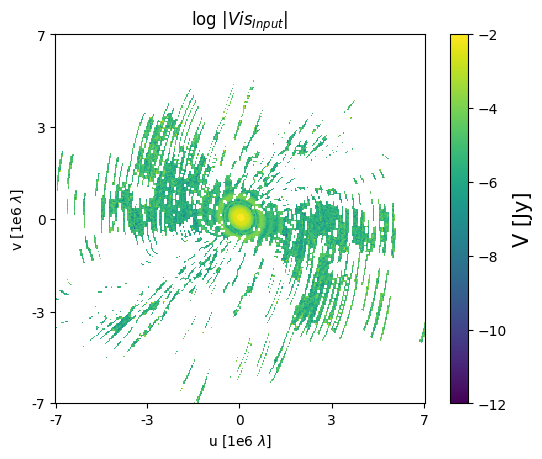

In [27]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [19]:
frank2d.frank1d(u, v, Vis, Weights)

In [20]:
vis_f1d = frank2d._frank1d_guess

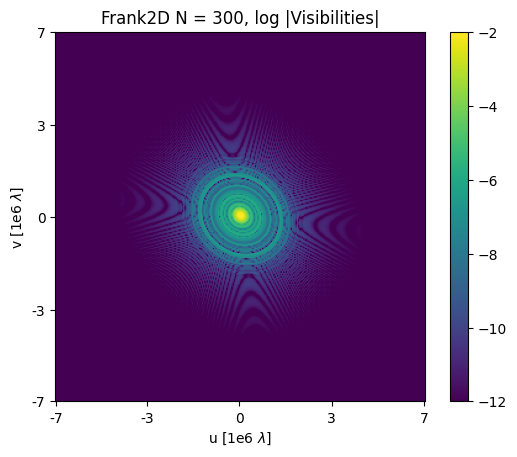

In [21]:
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_f1d).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(F'Frank2D N = {N}, log |Visibilities|')
plt.colorbar()

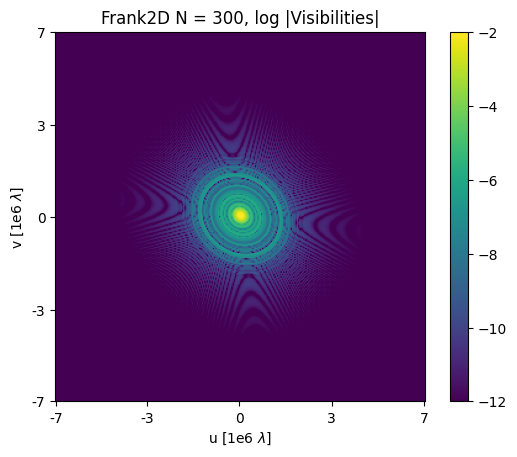

In [22]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_f1d.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(F'Frank2D N = {N}, log |Visibilities|')
plt.colorbar()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_92896/489374839.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


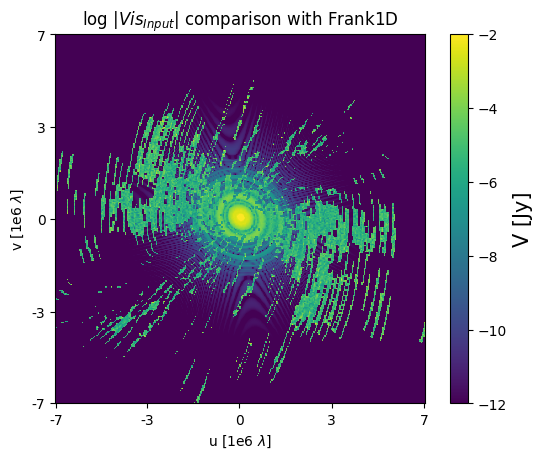

In [28]:
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_f1d).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$| comparison with Frank1D')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

### Running F2D

In [29]:
N = 300
m, c, l = -0.33, -0.1, 1e5

### Deprojected

In [32]:
start_time = time.time()

#####
frank2d_deprojected = Frank2D(N, Rout, Geometry(inc, pa, dra, ddec, deproject = True))
frank2d_deprojected.set_kernel('Wendland', [m, c, l])
frank2d_deprojected.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15)

#####
print("--------------------------------------")
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

Setting kernel: Wendland...
Gridding...
Deprojecting...


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


  --> time = 0.25  min |  15.04 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 6.17  min |  370.33 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 2.823724255715301e-09
         * maxiter:  900000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
             .. iteration:  17
             .. iteration:  18
  

In [35]:
frank2d_deprojected.fft()

Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


In [36]:
vis_sol_d = frank2d_deprojected.sol_visibility.reshape(N, N)

In [37]:
u_, v_ = frank2d_deprojected._FT._Un, frank2d_deprojected._FT._Vn

In [38]:
u_, v_ = np.fft.fftshift(u_.reshape(N, N)).flatten(), np.fft.fftshift(v_.reshape(N, N)).flatten()
vis_d = np.fft.fftshift(vis_sol_d).flatten()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_92896/3665059145.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_.reshape(N,N), u_.reshape(N,N), np.log(np.abs(vis_d.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)


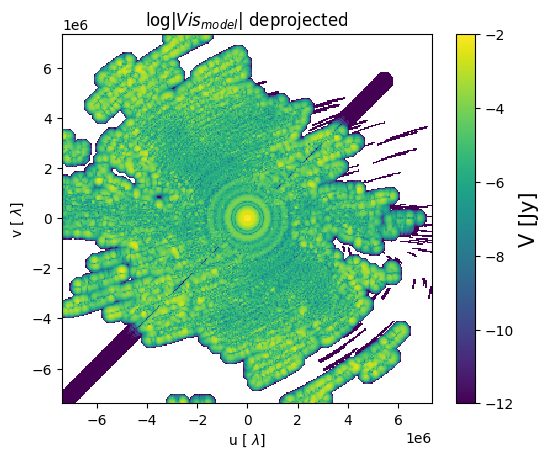

In [39]:
plt.pcolormesh(v_.reshape(N,N), u_.reshape(N,N), np.log(np.abs(vis_d.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$| deprojected')
plt.show()

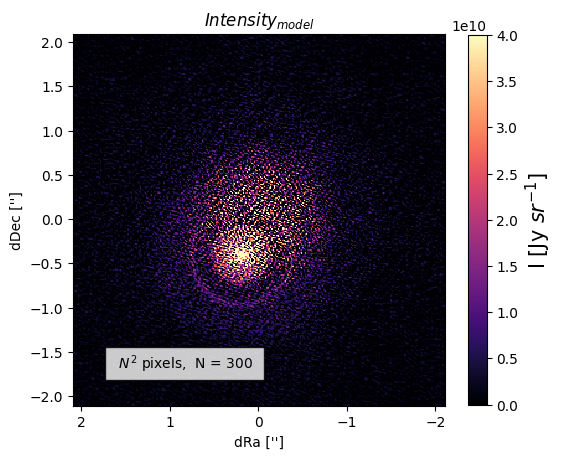

In [41]:
Plot(frank2d_deprojected, Geometry(inc, pa, dra, ddec, deproject = True)).get_image_intensity(r'$Intensity_{model}$', deprojected = False, fig_size = 6)

### Projected scheme

In [42]:
start_time = time.time()

#####
frank2d = Frank2D(N, Rout, Geometry(inc, pa, dra, ddec))
frank2d.set_kernel('Wendland', [m, c, l])
frank2d.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15, frank1d_guess = False)

#####
print("--------------------------------------")
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

Setting kernel: Wendland...
Gridding...
  --> time = 0.16  min |  9.39 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...


KeyboardInterrupt: 

In [43]:
vis_sol = frank2d.sol_visibility.reshape(N, N)

In [44]:
us, vs = np.fft.fftshift(frank2d._FT._Un.reshape(frank2d._FT._Nx, frank2d._FT._Ny)).flatten(), np.fft.fftshift(frank2d._FT._Vn.reshape(frank2d._FT._Nx, frank2d._FT._Ny)).flatten()
viss = np.fft.fftshift(vis_sol).flatten()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_90323/1572714159.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(vs.reshape(N,N), us.reshape(N,N), np.log(np.abs(viss.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)


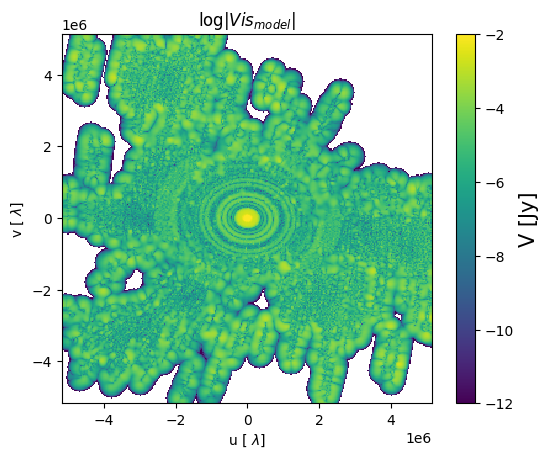

In [45]:
plt.pcolormesh(vs.reshape(N,N), us.reshape(N,N), np.log(np.abs(viss.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$|')
plt.show()

In [46]:
u_d, v_d,_ = Geometry(inc, pa, dra, ddec).deproject(us, vs)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_90323/2350905695.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_d.reshape(N,N), u_d.reshape(N,N), np.log(np.abs(viss.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)


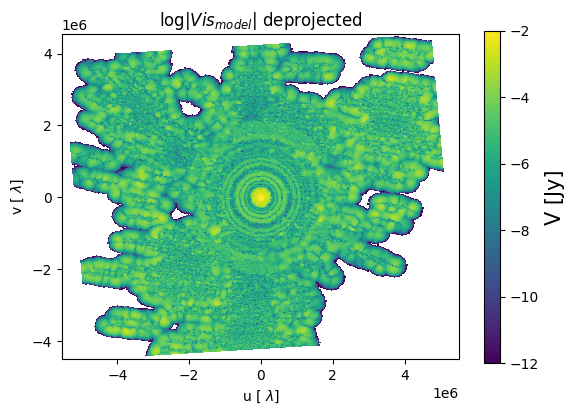

In [47]:
plt.pcolormesh(v_d.reshape(N,N), u_d.reshape(N,N), np.log(np.abs(viss.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal')
cmap = plt.colorbar(shrink =0.9)
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$| deprojected')
plt.show()

In [76]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [77]:
frank2d.fft()

Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


In [78]:
frank2d._FT._Xn

array([-1.45444104e-05, -1.45444104e-05, -1.45444104e-05, ...,
        1.44474477e-05,  1.44474477e-05,  1.44474477e-05])

In [79]:
x , y = frank2d._FT._Xn*rad_to_arcsec, frank2d._FT._Yn*rad_to_arcsec

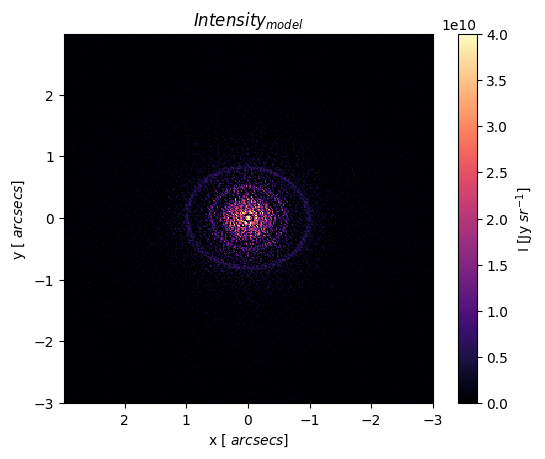

In [80]:
plt.pcolormesh(y.reshape(N,N), x.reshape(N,N), frank2d.sol_intensity, cmap = 'magma',  vmin = 0, vmax = 4e10)
plt.xlabel(r'x [ $arcsecs$]')
plt.ylabel(r'y [ $arcsecs$]')
plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()
plt.title(r'$Intensity_{model}$')
cmap = plt.colorbar()
cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)
plt.show()

In [53]:
x_d, y_d = deproject_real_space(frank2d)

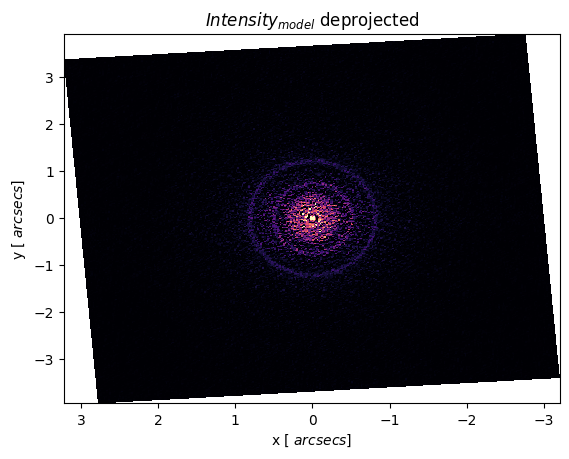

In [54]:
plt.clf()
plt.pcolormesh(y_d.reshape(N,N), x_d.reshape(N,N), frank2d.sol_intensity, cmap = 'magma',  vmin = 0, vmax = 4e10)
plt.xlabel(r'x [ $arcsecs$]')
plt.ylabel(r'y [ $arcsecs$]')

plt.gca().invert_xaxis()
plt.title(r'$Intensity_{model}$ deprojected')
#cmap = plt.colorbar()
#cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)
plt.show()

### Radial profile from the projected scheme

#### Trying the GOFISH approach

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Text(0, 0.5, 'Brightness Intensity (Jy/sr)')

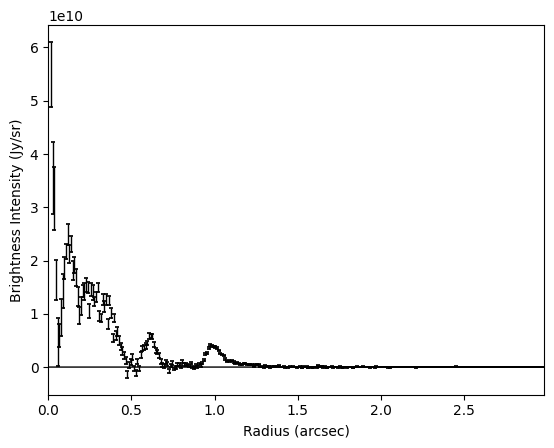

In [57]:
import gofish
from astropy.io import fits
import io
import tempfile

def radial_profile_gofish(frank2d, rvals, inc, PA):
    
    # Reshape the intensity data into a 2D image (Jy/sr)
    image_data = frank2d.sol_intensity.reshape(frank2d._FT._Nx, frank2d._FT._Nx)
    
    # Create a PrimaryHDU (FITS image)
    hdu = fits.PrimaryHDU(image_data)
    pixel_size = frank2d._FT._dx * rad_to_arcsec  # Convert pixel size to arcseconds
    
    # Create a header to define pixel scale and orientation
    header = hdu.header
    header['CDELT1'] = -pixel_size / 3600   # Pixel size in degrees (negative if axis decreases)
    header['CDELT2'] = pixel_size / 3600    # Pixel size in degrees
    header['CRPIX1'] = image_data.shape[1] / 2  # Image center in X
    header['CRPIX2'] = image_data.shape[0] / 2  # Image center in Y
    header['CRVAL1'] = 0  # Central coordinate (RA)
    header['CRVAL2'] = 0  # Central coordinate (Dec)
    header['CTYPE1'] = 'RA---TAN'  # Projection type
    header['CTYPE2'] = 'DEC--TAN'
    header['BUNIT'] = 'Jy/sr'  # Image units
    
    # Create a temporary FITS file
    with tempfile.NamedTemporaryFile(suffix=".fits", delete=True) as temp_fits:
        hdu.writeto(temp_fits.name, overwrite=True)
        
        # Load the FITS image into GoFish
        cube = gofish.imagecube(temp_fits.name)
        
        # Compute the radial profile
        x, y, dy = cube.radial_profile(rvals=rvals, inc=inc, PA=PA, shadowed = True)
    
    return x, y, dy


x_gofish, y_gofish, dy_gofish = radial_profile_gofish(frank2d, sol.r, inc, pa)    
fig, ax = plt.subplots()
ax.errorbar(x_gofish, y_gofish, dy_gofish, fmt=' ', capsize=1.25, capthick=1.25, color='k', lw=1.0)
ax.step(x, y, where='mid', color='k', lw=1.0)
ax.set_xlim(0, x.max())
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Brightness Intensity (Jy/sr)')

## Comparison

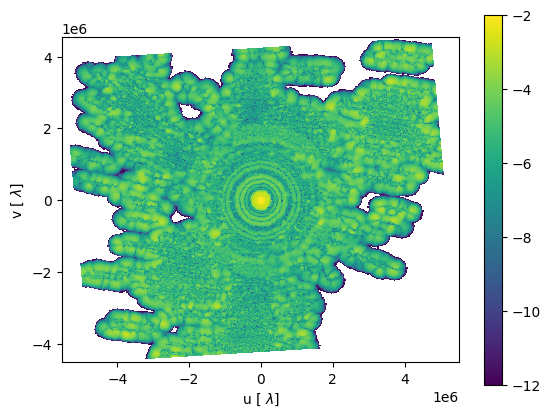

In [58]:
plt.pcolormesh(v_d.reshape(N,N), u_d.reshape(N,N),
               np.log(np.abs( np.fft.fftshift(frank2d.sol_visibility.reshape(N,N)) )),
               cmap="viridis", vmin=-12, vmax=-2)
plt.colorbar()
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
plt.show()

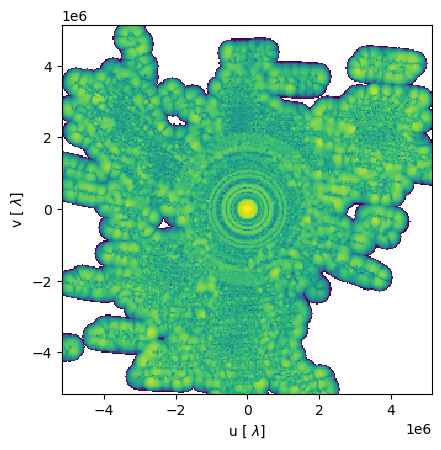

In [59]:
plt.pcolormesh(v_.reshape(N,N), u_.reshape(N,N),
               np.log(np.abs(np.fft.fftshift(frank2d_deprojected.sol_visibility.reshape(N,N)))),
               cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
plt.show()

## Frank1d

In [56]:
# Frank 1D Parameters
n_pts = 300
alpha = 1.3
w_smooth = 1e-3

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u, v, Vis, Weights)

#### Plots

In [60]:
I2D_deprojected, xmax_out_deprojected, ymax_out_deprojected = sweep_profile(sol.r, sol.mean, project= False, phase_shift = False, geom = {'inc': inc, 'pa':pa, 'dra':dra, 'ddec':ddec}, xmax = x.max(), ymax = y.max(), dr = (sol.r[1] - sol.r[0]))


301
(301, 301)


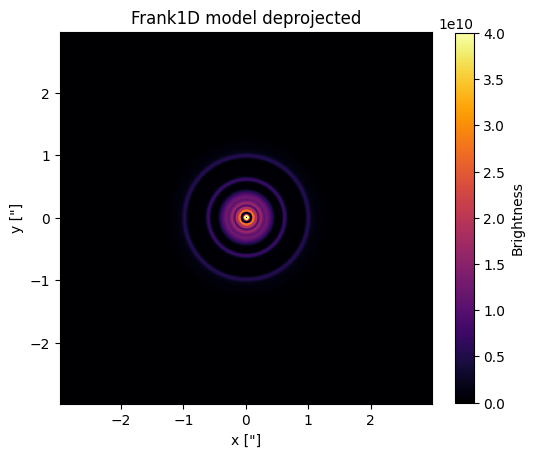

In [61]:
x_deprojected = np.linspace(-xmax_out_deprojected, xmax_out_deprojected, I2D_deprojected.shape[1])
y_deprojected = np.linspace(-ymax_out_deprojected, ymax_out_deprojected, I2D_deprojected.shape[0])

plt.figure(figsize=(6, 6))
extent = [-xmax_out_deprojected, xmax_out_deprojected, -ymax_out_deprojected, ymax_out_deprojected]  # Extensión del gráfico
plt.imshow(I2D_deprojected, extent=extent, origin='lower', cmap='inferno', aspect='auto', vmin = -1, vmax = 4e10)
plt.colorbar(label='Brightness', shrink= 0.8)
plt.xlabel('x ["]')
plt.ylabel('y ["]')
plt.title('Frank1D model deprojected', size= 12)
plt.gca().set_aspect('equal') 
plt.show()


In [62]:
I2D, xmax_out, ymax_out = sweep_profile(sol.r, sol.mean, project= True, phase_shift = False, geom = {'inc': inc, 'pa':pa, 'dra':dra, 'ddec':ddec}, xmax = x.max(), ymax = y.max(), dr =  (sol.r[1] - sol.r[0]))

301
(301, 301)


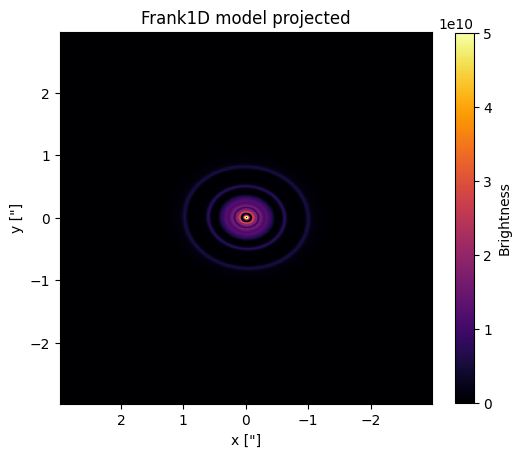

In [63]:
x = np.linspace(-xmax_out, xmax_out, I2D.shape[1])
y = np.linspace(-ymax_out, ymax_out, I2D.shape[0])

plt.figure(figsize=(6, 6))
extent = [xmax_out, -xmax_out, -ymax_out, ymax_out]  # Extensión del gráfico
plt.imshow(I2D, extent=extent, origin='lower', cmap='inferno', aspect='auto',  vmin = 0, vmax = 5e10)
plt.colorbar(label='Brightness', shrink= 0.8)
plt.xlabel('x ["]')
plt.ylabel('y ["]')
plt.title('Frank1D model projected', size = 12)
plt.gca().set_aspect('equal') 
plt.show()

## Comparison with Frank1D

### Fourier space

In [96]:
u_gridded_d, v_gridded_d, _= Geometry(inc, pa, dra, ddec).deproject(u_gridded, v_gridded)

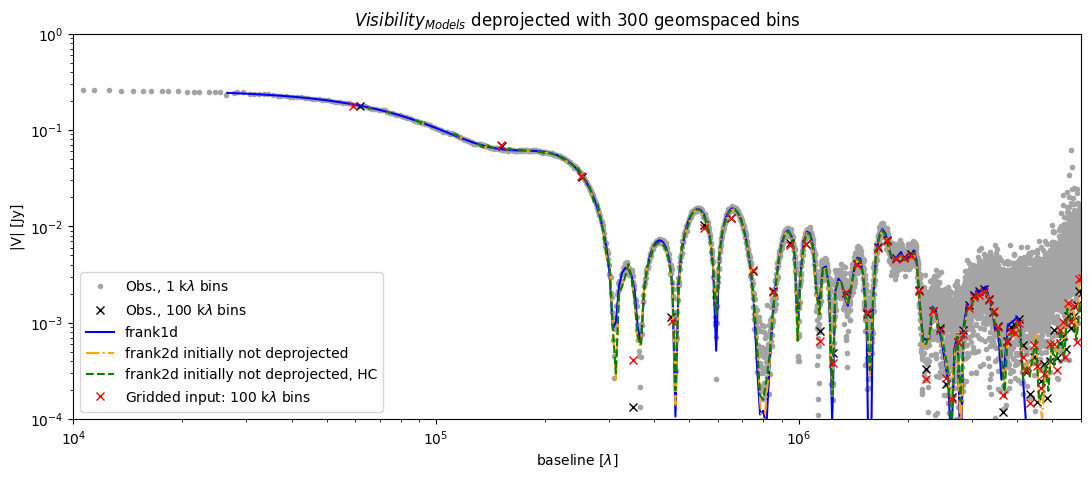

In [101]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(13,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# --------------------------LOG BINS----------------------------------------------------------
#frank1d
Nbins = 300
baselines_edges = np.geomspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
#frank2d
q, Vis = get_vis_profile_deprojected(frank2d, baselines_edges, range, weighted = True)
plt.plot(baselines_centers, np.abs(Vis), label = f'frank2d initially not deprojected', ls= '-.', color = 'orange')

#frank2d deprojected
q, Vis_d = get_vis_profile_deprojected(frank2d_deprojected, baselines_edges, range, weighted = True)
plt.plot(baselines_centers, np.abs(Vis_d), label = f'frank2d initially not deprojected, HC',ls='--', color = 'green')


# ---------------------------------------------------------------------------------------------
# Gridded visibilities
baselines_gridded_d = np.hypot(u_gridded_d, v_gridded_d)  
binned_vis_gridded = UVDataBinner(baselines_gridded_d, vis_gridded, weights_gridded, bin_widths[1])
plt.plot(binned_vis_gridded.uv, np.abs(binned_vis_gridded.V), c='red',
             marker=ms[1], ls='None', 
             label=r'Gridded input: {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-4, 1)
plt.xlim(1e4, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) + ' geomspaced bins')
plt.legend(fontsize= 10)
plt.show()

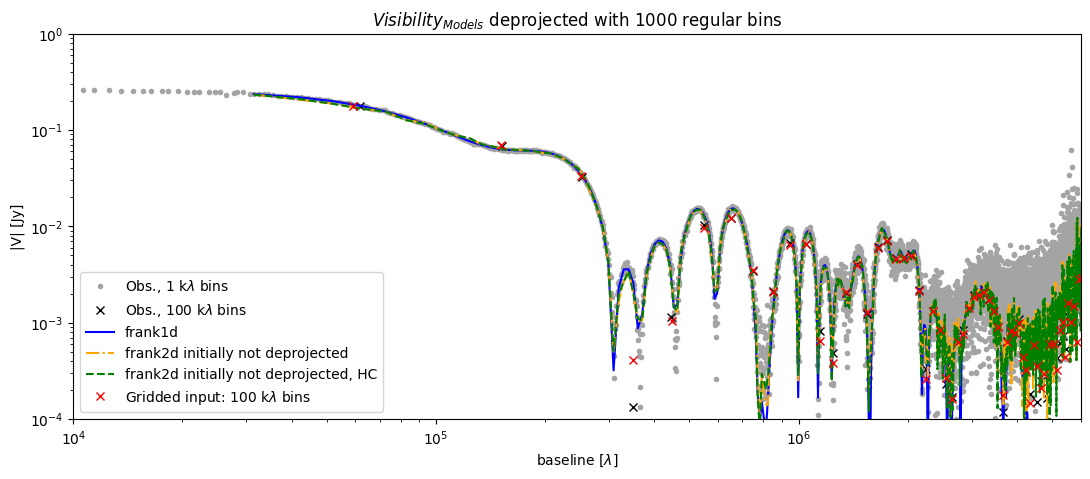

In [103]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(13,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -----------------LINSPACE BINS--------------------------------------------------------------
#frank1d
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = baselines_edges[:-1] + (baselines_edges[1] - baselines_edges[0])/2
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
#frank2d
q, Vis = get_vis_profile_deprojected(frank2d, Nbins, range, weighted = True)
plt.plot(baselines_centers, np.abs(Vis), label = f'frank2d initially not deprojected', ls= '-.', color = 'orange')

#frank2d deprojected
q, Vis_d = get_vis_profile_deprojected(frank2d_deprojected, Nbins, range, weighted = True)
plt.plot(baselines_centers, np.abs(Vis_d), label = f'frank2d initially not deprojected, HC',ls='--', color = 'green')


# ---------------------------------------------------------------------------------------------
# Gridded visibilities
baselines_gridded_d = np.hypot(u_gridded_d, v_gridded_d)  
binned_vis_gridded = UVDataBinner(baselines_gridded_d, vis_gridded, weights_gridded, bin_widths[1])
plt.plot(binned_vis_gridded.uv, np.abs(binned_vis_gridded.V), c='red',
             marker=ms[1], ls='None', 
             label=r'Gridded input: {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-4, 1)
plt.xlim(1e4, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) + ' regular bins')
plt.legend(fontsize= 10)
plt.show()

### Real space

In [104]:
cos_i =  np.cos(frank2d._Geometry._inc*deg_to_rad)

In [105]:
dr = (sol.r[1] - sol.r[0])/2
bin_edges = np.concatenate((sol.r - dr, [sol.r[-1] + dr]))

In [109]:
r_f2d_deprojected, I_f2d_deprojected = get_radial_profile_deprojected(frank2d_deprojected, bin_edges, (sol.r[0], sol.r[-1]))
r_f2d_projected_d, I_f2d_projected_d = get_radial_profile_deprojected(frank2d, bin_edges, (sol.r[0], sol.r[-1]))

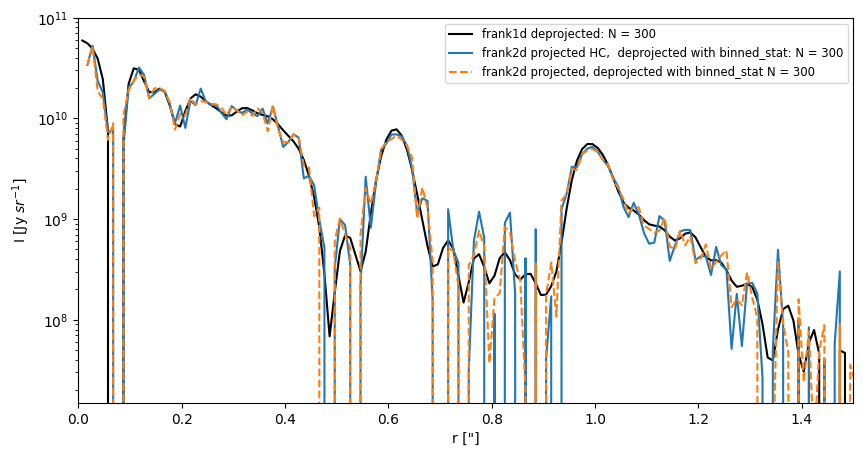

In [111]:
plt.figure(figsize=(10,5))
plt.plot(sol.r, sol.mean, 'black',label =f'frank1d deprojected: N = {n_pts}')
plt.plot(sol.r, I_f2d_deprojected, label = f'frank2d projected HC,  deprojected with binned_stat: N = {N}')
plt.plot(sol.r, I_f2d_projected_d, label = f'frank2d projected, deprojected with binned_stat N = {N}', ls='--')
#plt.fill_between(x_gofish, y_gofish - dy_gofish, y_gofish + dy_gofish, color='red', alpha=0.2)
#plt.plot(x_gofish, y_gofish, label = f'frank2d projected, deprojected gofish: N = {N}',  ls='--', color ='red')
plt.xlabel('r ["]')
plt.xlim(0,1.5)      
plt.ylim(1.5e7, 1e11)
plt.ylabel(r'I [Jy $sr^{-1}$]')
plt.legend(fontsize = 'small')
plt.yscale("log")
plt.show()

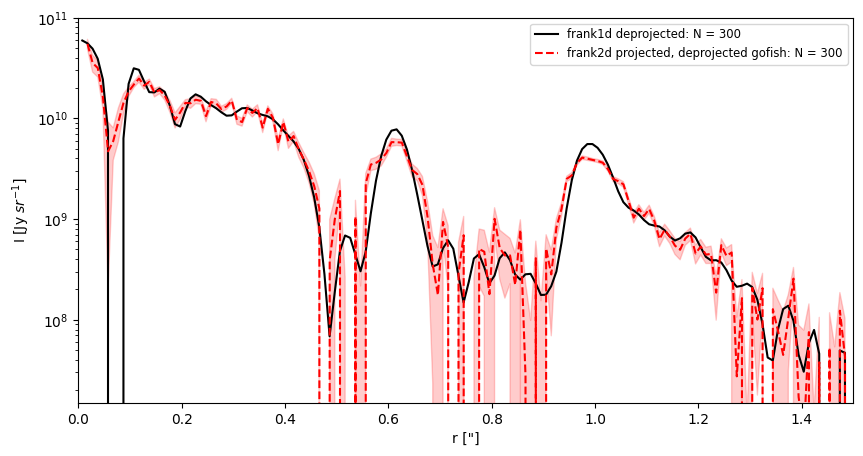

In [112]:
plt.figure(figsize=(10,5))
plt.plot(sol.r, sol.mean, 'black',label =f'frank1d deprojected: N = {n_pts}')
plt.fill_between(x_gofish, y_gofish - dy_gofish, y_gofish + dy_gofish, color='red', alpha=0.2)

plt.plot(x_gofish, y_gofish, label = f'frank2d projected, deprojected gofish: N = {N}',  ls='--', color ='red')
plt.xlabel('r ["]')
plt.xlim(0,1.5)      
plt.ylim(1.5e7, 1e11)
plt.ylabel(r'I [Jy $sr^{-1}$]')
plt.legend(fontsize = 'small')
plt.yscale("log")
plt.show()

## Comparing with CLEAN

In [113]:
# Obtain the radial profiles convolved to a circular beam.
from gofish import imagecube

infile_1mm = dir + 'AS209_1mm_13s_conv_circ.fits'
#2D->1D
cube_1mm = imagecube(infile_1mm)
x_1mm,y_1mm,dy_1mm = cube_1mm.radial_profile(inc=inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [114]:
from frank.utilities import convolve_profile

clean_beam_1mm = {'bmaj':0.0373, 'bmin':0.0373, 'beam_pa':31.040}
area_1mm = clean_beam_1mm['bmaj']*clean_beam_1mm['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

convolved_1mm_frank2d = convolve_profile(r_f2d_projected_d[1:], I_f2d_projected_d[1:], inc, pa, clean_beam_1mm)*area_1mm
convolved_1mm_frank1d = convolve_profile(sol.r, sol.mean, inc, pa, clean_beam_1mm)*area_1mm

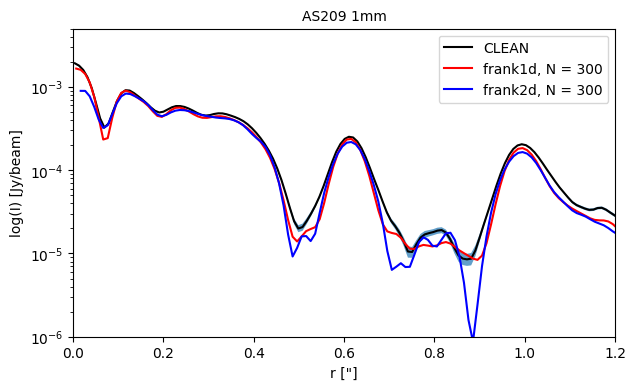

In [115]:
plt.figure(figsize=(7, 4))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(sol.r, convolved_1mm_frank1d, "red", label=r'frank1d' + ', N = ' +str(n_pts))
plt.plot(sol.r[1:],convolved_1mm_frank2d, "blue", label=r'frank2d' + ', N = ' +str(N))
plt.title(disk_name, size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=10)
plt.yscale('log')
plt.ylim(0.1e-5, 0.5e-2)
plt.xlim(0,1.2)
plt.show()